Implementation of a multi-layer perceptron

In [1]:
import torch
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b

o = torch.tanh(n)

print(o.data.item())
o.backward()

print('------')
print('x1.grad', x1.grad.item())
print('x2.grad', x2.grad.item())
print('w1.grad', w1.grad.item())
print('w2.grad', w2.grad.item())


0.7071066904050358
------
x1.grad -1.5000003851533106
x2.grad 0.5000001283844369
w1.grad 1.0000002567688737
w2.grad 0.0


In [3]:
# Data structure to maintain mathematical expressions for neural network
import math
class Value:
    def __init__(self, data, _children=(), _op ='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    # To print data
    def __repr__(self):
        return f"Value(data={self.data})"
   
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    # To support operations like 2 * a
    def __rmul__(self, other):
        # This will call  __mul__
        return self * other

    # for self / other
    def __truediv__(self, other):
        return self * other**-1

    # for -self
    def __neg__(self):
        return self * -1

    # for self - other
    def __sub__(self, other):
        return self + (-other)

    # To support operations like 2 + a
    def __radd__(self, other):
        return self + other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    # Exponentiation
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
   
    # Activation function for NN, we are using hyperbolic function here 
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out 

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1
        for node in reversed(topo):
            node._backward()

In [4]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
          # For graph purpose, child is going into/feeding into parent
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [5]:
# Node in NN
class Neuron:

  # nin = number of inputs a neuron will receive
  # w = weights -> for each nin, generate a random weight between -1,1
  # bias -> random number between -1 to 1
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  # w*x+b
  # zip(self.w, x) pairs up elements from two iterables side by side, producing tuples.
  # self.w = [0.5, -0.3, 0.8]
  # x      = [2.0,  1.0, 3.0]
  # zip(self.w, x) → (0.5, 2.0), (-0.3, 1.0), (0.8, 3.0)
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
      
  # returns weight and bias of a neuron
  def parameters(self):
    return self.w + [self.b]

class Layer:
  # nin -> number of input each neuron will receive
  # nout -> number of neurons in each layer
  def __init__(self, nin, nout):
    # It is creating nout number of neurons where each neuron will have nin number of input
    self.neurons = [Neuron(nin) for _ in range(nout)]

  # When you iterate over `for n in self.neurons`, each `n` is a Neuron object. 
  # That's why `n(x)` calls `Neuron.__call__(x)`.
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    # sz will create a single list consisting of valus from nin and nout
    sz = [nin] + nouts
    # Here nout is kind of defining number of layers
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
     # output of all the neurons in each layer is being fed as input 
        # to all the neurons in next layer. Thats why x will always be overriden.
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [6]:
# Define NN
n = MLP(3, [4, 4, 1])
# data set -> 3 inputs
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [7]:
# Training loop
for k in range(20):
    # forward pass (prediction)
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    ## loss is a Value object carries a computation graph.
    # Every time we do an operation on `Value` objects, it secretly builds a graph of how everything is connected/computed:
    # ```
    # w1 ──────────────────────────────────────────╮
    #       w1*x1 ──╮                               │
    # x1 ──────────╯  w1*x1+w2*x2 ──╮              │
    #                                  act ──╮       │
    # x2 ──────────╮  w1*x1+w2*x2 ──╯       │       │
    #       w2*x2 ──╯                  tanh ──╮     │
    # w2 ──────────────────────────────────╯  │     │
    #                                     pred ──╮  │
    # b  ──────────────────────────────────────╯  │  │
    #                                        loss ←──╯
    # It calculates gradient through backpropogation
    loss.backward()

    # update weights and bias
    # Formula to update weights and bias through gradient descent
    # New weight = old weight + step size
    # step size = slope * learning rate. Here slope is p.grad and -0.1 is learning rate
    for p in n.parameters():
        p.data += -0.1*p.grad

    print(k, loss.data)

0 7.280129136738302
1 3.4790528247534436
2 1.2373485289533512
3 0.8676699027967945
4 0.13940331870256875
5 0.052600062196931925
6 0.03690632081650378
7 0.02933176886297386
8 0.024759153824255756
9 0.02165249019051402
10 0.019377825850761095
11 0.017623658962028478
12 0.01621848554794177
13 0.01505987395524537
14 0.014082750089328919
15 0.013243705719443504
16 0.012512611473692916
17 0.011867851260091608
18 0.011293475865875825
19 0.010777430583038301


In [8]:
ypred

[Value(data=0.9675297967646285),
 Value(data=-0.9603573108094234),
 Value(data=-0.9258306133332075),
 Value(data=0.94851722851183)]

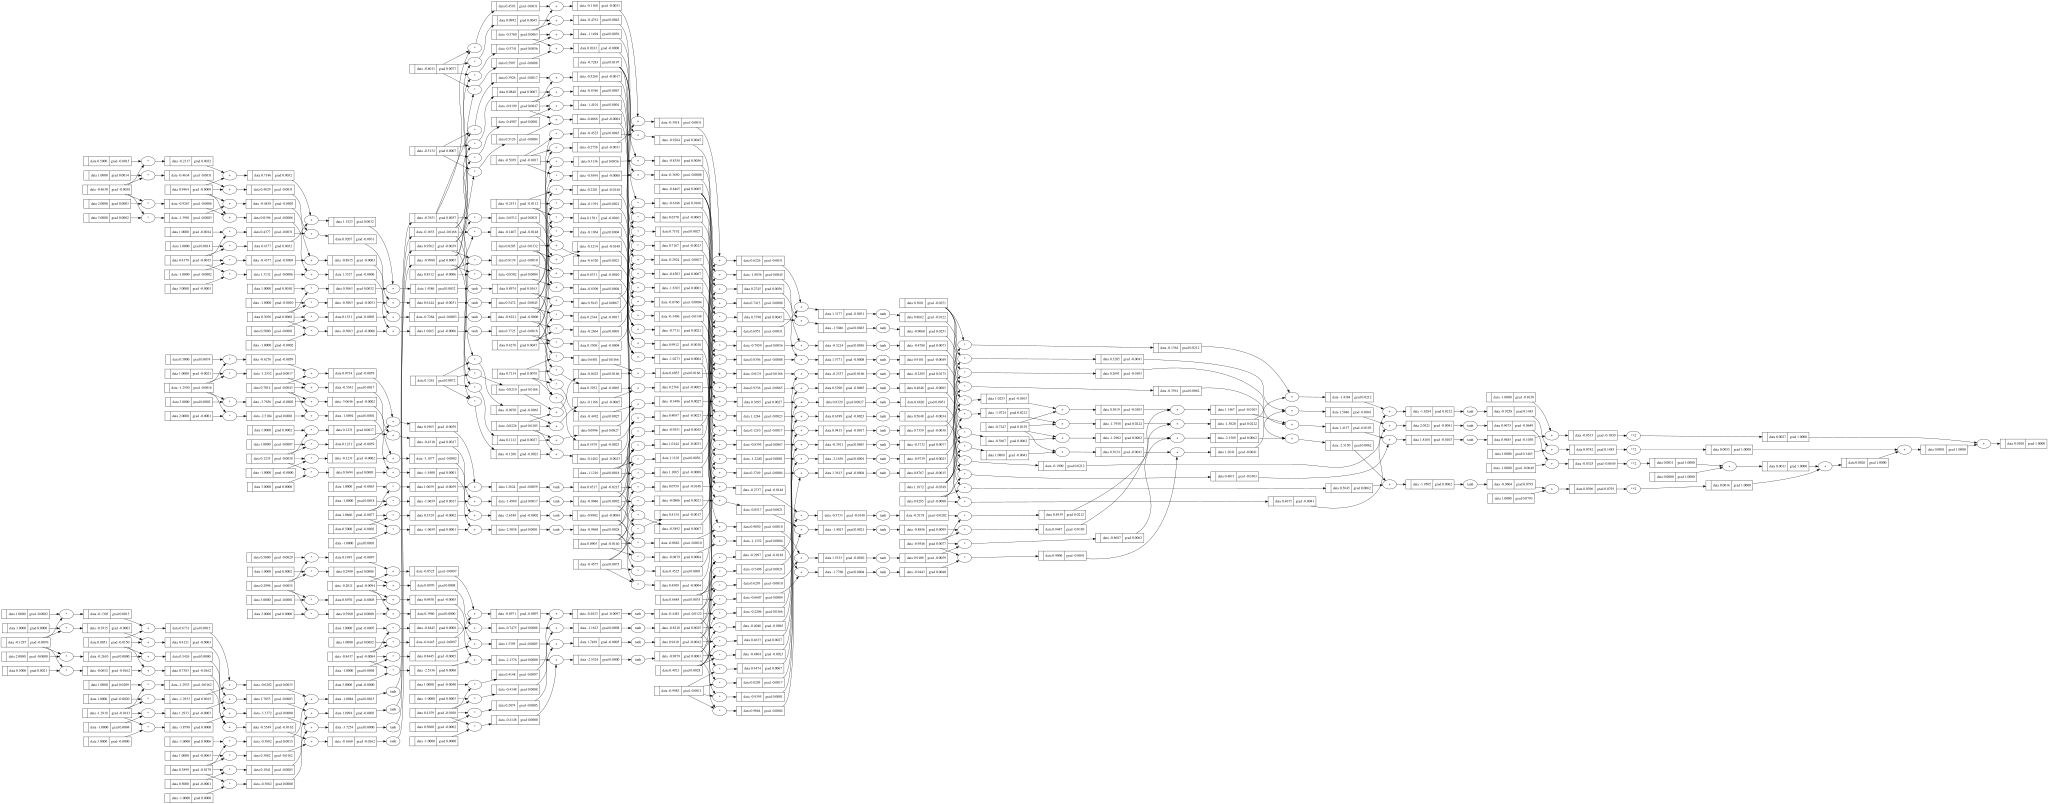

In [9]:
draw_dot(loss)